In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

In [2]:
print (pd.__version__)

2.2.2


In [13]:
df = pd.read_csv(r'D:\Projects\Intellectra\ML-KOMPETISI-INTELLECTRA-2025-IPB\dataset\train_label_data.csv', low_memory=False)
num_rows = len(df)
print(f"sebelum di filter: {num_rows}")
df.head(26)

sebelum di filter: 40020


,MemberID,next_buy
0,7ef72aa51aecb701dc5c4074480fcdf6,0
1,577f1b9a093c2cec6398b1118f5d99ab,0
2,e2ee74f248a74ed886a22f14348fbafd,0
3,cefa8ef7469a8b4e6df3f745d4905000,0
4,5eecda17ddf06ed9d79f298b13f84785,0
5,51b86190f095fc26d50fb885ccf3882f,1
6,d90dfeb1f33779390d1170d27e9fb791,0
7,8ccc5cccb5a8531cf2bf7f73ef5745d9,0
8,467aeb812e8fb65091d10ca22c95e204,0
9,f3b5eaa60ddf26eca40537fbc6df3242,0


In [41]:
df = pd.read_csv(r'D:\Projects\Intellectra\ML-KOMPETISI-INTELLECTRA-2025-IPB\dataset\train_transaction_data.csv', low_memory=False)
num_rows = len(df)
print(f"sebelum di filter: {num_rows}")
df.head(10)

sebelum di filter: 130854


,TransactionID,MemberID,Source,FK_PRODUCT_ID,FK_PROD_GRAM_ID,Qty,PricePerUnit,TransactionDatetime
0,ffd6c035bef03a2c386caf2552148fb2402b0b24,7ef72aa51aecb701dc5c4074480fcdf6,ELANG,27,52,1,NaN,2020-07-01 07:41:00 UTC
1,4fadf10aff7e250cc8d63badeaefdf383c0e1c13,577f1b9a093c2cec6398b1118f5d99ab,ALFAMART,22,39,1,290000.0,2020-07-01 07:24:00 UTC
2,7299df1aaf47b52017f58dd8e59df1fe37072670,e2ee74f248a74ed886a22f14348fbafd,EKTONG,22,39,1,263500.0,2020-07-01 09:13:00 UTC
3,22dae0e1e8bb87601eabd712721bd249739bc620,cefa8ef7469a8b4e6df3f745d4905000,CITRA,27,52,3,145000.0,2020-07-01 08:28:00 UTC
4,6a744d5d79e09b0c1646e604db1c4ec65eff73d7,5eecda17ddf06ed9d79f298b13f84785,INDOMARET,27,52,1,165900.0,2020-07-01 07:02:00 UTC
5,d3026abcfe11329fe2681fde2959eb27cecacc0f,51b86190f095fc26d50fb885ccf3882f,CLANDYS,22,39,2,264100.0,2020-07-01 09:02:00 UTC
6,da947a08c0c494ce2429068f3e556f1cf82a7238,d90dfeb1f33779390d1170d27e9fb791,SINAR MAKMUR,22,39,1,271000.0,2020-07-01 10:16:00 UTC
7,c014232fa64aa4d6a0a7d8575f249ccfad9d96b4,8ccc5cccb5a8531cf2bf7f73ef5745d9,ALFAMART,26,49,2,85400.0,2020-07-01 07:08:00 UTC
8,8002f832daccd3ba5d581ad69e16216e9bba1054,467aeb812e8fb65091d10ca22c95e204,BRAVO,27,52,4,154500.0,2020-07-01 10:18:00 UTC
9,6fe98d766f57fc5f8ca5639d1cb9a18421621717,f3b5eaa60ddf26eca40537fbc6df3242,CLANDYS,22,39,2,262900.0,2020-07-01 10:22:00 UTC


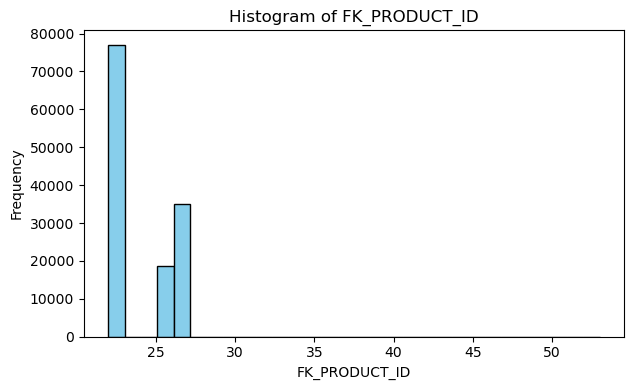

In [42]:
columns = ['FK_PRODUCT_ID']

num_cols = 2 
num_rows = (len(columns) + num_cols - 1) // num_cols

plt.figure(figsize=(12, num_rows * 4))

for i, col in enumerate(columns):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [38]:
null_count= df.isnull().sum()
print(null_count)

TransactionID              0
MemberID                   0
Source                     0
FK_PRODUCT_ID              0
FK_PROD_GRAM_ID            0
Qty                        0
PricePerUnit           19173
TransactionDatetime        0
dtype: int64


In [3]:
# Load the datasets
try:
    train_transaction_data = pd.read_csv(r'D:\Projects\Intellectra\ML-KOMPETISI-INTELLECTRA-2025-IPB\dataset\train_transaction_data.csv')
    member_data = pd.read_csv(r'D:\Projects\Intellectra\ML-KOMPETISI-INTELLECTRA-2025-IPB\dataset\member_data.csv')
    product_data = pd.read_csv(r'D:\Projects\Intellectra\ML-KOMPETISI-INTELLECTRA-2025-IPB\dataset\product_data.csv')
    prodgram_data = pd.read_csv(r'D:\Projects\Intellectra\ML-KOMPETISI-INTELLECTRA-2025-IPB\dataset\prodgram_data.csv')
    train_label = pd.read_csv(r'D:\Projects\Intellectra\ML-KOMPETISI-INTELLECTRA-2025-IPB\dataset\train_label_data.csv')
except FileNotFoundError as e:
    print(f"Error loading data: {e}. Please ensure all files are in the correct path.")
    # As a fallback for demonstration if files are not found, create empty dataframes with expected columns.
    train_transaction_data = pd.DataFrame(columns=['TransactionID', 'MemberID', 'Source', 'FK_PRODUCT_ID', 'FK_PROD_GRAM_ID', 'Qty', 'PricePerUnit', 'TransactionDatetime'])
    member_data = pd.DataFrame(columns=['MemberID', 'JoinDate', 'DateOfBirth', 'City', 'NoOfChild', 'EldestKidDOB', 'YoungestKidDOB'])
    product_data = pd.DataFrame(columns=['PRODUCT_ID', 'ProdName', 'BRAND_ID'])
    prodgram_data = pd.DataFrame(columns=['PROD_GRAM_ID', 'ProdGram', 'MinQty', 'MaxQty'])
    train_label = pd.DataFrame(columns=['MemberID','next_buy'])


# Merge the dataframes
merged_data = pd.merge(train_transaction_data, member_data, on='MemberID', how='left')
merged_data = pd.merge(merged_data, product_data, left_on='FK_PRODUCT_ID', right_on='productID', how='left')
merged_data = pd.merge(merged_data, prodgram_data, left_on='FK_PROD_GRAM_ID', right_on='prodgramID', how='left')
merged_data = pd.merge(merged_data, train_label, left_on='MemberID', right_on='MemberID', how='left')

# Display the first few rows of the aggregated data
merged_data.head(10)

,TransactionID,MemberID,Source,FK_PRODUCT_ID,FK_PROD_GRAM_ID,Qty,PricePerUnit,TransactionDatetime,JoinDate,DateOfBirth,...,YoungestKidDOB,productID,ProductName,ProductCategory,ProductLevel,prodgramID,GrammageName,Point,Price,next_buy
0,ffd6c035bef03a2c386caf2552148fb2402b0b24,7ef72aa51aecb701dc5c4074480fcdf6,ELANG,27,52,1,NaN,2020-07-01 07:41:00 UTC,2019-12-24,NaN,...,2017-07-31,27,A,A,Original,52,700 GR,50,201000.0,0
1,4fadf10aff7e250cc8d63badeaefdf383c0e1c13,577f1b9a093c2cec6398b1118f5d99ab,ALFAMART,22,39,1,290000.0,2020-07-01 07:24:00 UTC,2019-08-29,NaN,...,2019-01-27,22,A G,A,Premium,39,900 GR,100,300000.0,0
2,7299df1aaf47b52017f58dd8e59df1fe37072670,e2ee74f248a74ed886a22f14348fbafd,EKTONG,22,39,1,263500.0,2020-07-01 09:13:00 UTC,2018-06-19,NaN,...,2019-04-10,22,A G,A,Premium,39,900 GR,100,300000.0,0
3,22dae0e1e8bb87601eabd712721bd249739bc620,cefa8ef7469a8b4e6df3f745d4905000,CITRA,27,52,3,145000.0,2020-07-01 08:28:00 UTC,2019-05-06,NaN,...,2016-11-16,27,A,A,Original,52,700 GR,50,201000.0,0
4,6a744d5d79e09b0c1646e604db1c4ec65eff73d7,5eecda17ddf06ed9d79f298b13f84785,INDOMARET,27,52,1,165900.0,2020-07-01 07:02:00 UTC,2020-05-05,NaN,...,2018-05-22,27,A,A,Original,52,700 GR,50,201000.0,0
5,d3026abcfe11329fe2681fde2959eb27cecacc0f,51b86190f095fc26d50fb885ccf3882f,CLANDYS,22,39,2,264100.0,2020-07-01 09:02:00 UTC,2020-05-26,NaN,...,2019-03-23,22,A G,A,Premium,39,900 GR,100,300000.0,1
6,da947a08c0c494ce2429068f3e556f1cf82a7238,d90dfeb1f33779390d1170d27e9fb791,SINAR MAKMUR,22,39,1,271000.0,2020-07-01 10:16:00 UTC,2019-07-12,NaN,...,2018-07-01,22,A G,A,Premium,39,900 GR,100,300000.0,0
7,c014232fa64aa4d6a0a7d8575f249ccfad9d96b4,8ccc5cccb5a8531cf2bf7f73ef5745d9,ALFAMART,26,49,2,85400.0,2020-07-01 07:08:00 UTC,2019-10-14,NaN,...,2016-04-26,26,B,B,Original,49,400 GR,25,102000.0,0
8,8002f832daccd3ba5d581ad69e16216e9bba1054,467aeb812e8fb65091d10ca22c95e204,BRAVO,27,52,4,154500.0,2020-07-01 10:18:00 UTC,2020-05-19,NaN,...,2019-05-17,27,A,A,Original,52,700 GR,50,201000.0,0
9,6fe98d766f57fc5f8ca5639d1cb9a18421621717,f3b5eaa60ddf26eca40537fbc6df3242,CLANDYS,22,39,2,262900.0,2020-07-01 10:22:00 UTC,2020-01-04,NaN,...,2018-12-25,22,A G,A,Premium,39,900 GR,100,300000.0,0


In [4]:
null_count= merged_data.isnull().sum()
print(null_count)

TransactionID               0
MemberID                    0
Source                      0
FK_PRODUCT_ID               0
FK_PROD_GRAM_ID             0
Qty                         0
PricePerUnit            19173
TransactionDatetime         0
JoinDate                    0
DateOfBirth            124162
City                        0
NoOfChild                   0
EldestKidDOB                0
YoungestKidDOB              0
productID                   0
ProductName                 0
ProductCategory             0
ProductLevel                0
prodgramID                  0
GrammageName                0
Point                       0
Price                       0
next_buy                    0
dtype: int64


In [5]:
merged_data = merged_data.drop("DateOfBirth", axis='columns')
merged_data.head(10)

,TransactionID,MemberID,Source,FK_PRODUCT_ID,FK_PROD_GRAM_ID,Qty,PricePerUnit,TransactionDatetime,JoinDate,City,...,YoungestKidDOB,productID,ProductName,ProductCategory,ProductLevel,prodgramID,GrammageName,Point,Price,next_buy
0,ffd6c035bef03a2c386caf2552148fb2402b0b24,7ef72aa51aecb701dc5c4074480fcdf6,ELANG,27,52,1,NaN,2020-07-01 07:41:00 UTC,2019-12-24,BEKASI,...,2017-07-31,27,A,A,Original,52,700 GR,50,201000.0,0
1,4fadf10aff7e250cc8d63badeaefdf383c0e1c13,577f1b9a093c2cec6398b1118f5d99ab,ALFAMART,22,39,1,290000.0,2020-07-01 07:24:00 UTC,2019-08-29,JAMBI,...,2019-01-27,22,A G,A,Premium,39,900 GR,100,300000.0,0
2,7299df1aaf47b52017f58dd8e59df1fe37072670,e2ee74f248a74ed886a22f14348fbafd,EKTONG,22,39,1,263500.0,2020-07-01 09:13:00 UTC,2018-06-19,MAKASAR,...,2019-04-10,22,A G,A,Premium,39,900 GR,100,300000.0,0
3,22dae0e1e8bb87601eabd712721bd249739bc620,cefa8ef7469a8b4e6df3f745d4905000,CITRA,27,52,3,145000.0,2020-07-01 08:28:00 UTC,2019-05-06,SIDOARJO,...,2016-11-16,27,A,A,Original,52,700 GR,50,201000.0,0
4,6a744d5d79e09b0c1646e604db1c4ec65eff73d7,5eecda17ddf06ed9d79f298b13f84785,INDOMARET,27,52,1,165900.0,2020-07-01 07:02:00 UTC,2020-05-05,SUKABUMI,...,2018-05-22,27,A,A,Original,52,700 GR,50,201000.0,0
5,d3026abcfe11329fe2681fde2959eb27cecacc0f,51b86190f095fc26d50fb885ccf3882f,CLANDYS,22,39,2,264100.0,2020-07-01 09:02:00 UTC,2020-05-26,SLEMAN,...,2019-03-23,22,A G,A,Premium,39,900 GR,100,300000.0,1
6,da947a08c0c494ce2429068f3e556f1cf82a7238,d90dfeb1f33779390d1170d27e9fb791,SINAR MAKMUR,22,39,1,271000.0,2020-07-01 10:16:00 UTC,2019-07-12,BLITAR,...,2018-07-01,22,A G,A,Premium,39,900 GR,100,300000.0,0
7,c014232fa64aa4d6a0a7d8575f249ccfad9d96b4,8ccc5cccb5a8531cf2bf7f73ef5745d9,ALFAMART,26,49,2,85400.0,2020-07-01 07:08:00 UTC,2019-10-14,SEMARANG,...,2016-04-26,26,B,B,Original,49,400 GR,25,102000.0,0
8,8002f832daccd3ba5d581ad69e16216e9bba1054,467aeb812e8fb65091d10ca22c95e204,BRAVO,27,52,4,154500.0,2020-07-01 10:18:00 UTC,2020-05-19,JOMBANG,...,2019-05-17,27,A,A,Original,52,700 GR,50,201000.0,0
9,6fe98d766f57fc5f8ca5639d1cb9a18421621717,f3b5eaa60ddf26eca40537fbc6df3242,CLANDYS,22,39,2,262900.0,2020-07-01 10:22:00 UTC,2020-01-04,SLEMAN,...,2018-12-25,22,A G,A,Premium,39,900 GR,100,300000.0,0


In [8]:
sorted_data = merged_data.sort_values(by='MemberID')
print("DataFrame sorted by MemberID.")

print(sorted_data.head(10))

DataFrame sorted by MemberID.
                                   TransactionID  \
77159   77bd72841044a90b655cbc3cf186a57ca883f841   
39590   a743feb757c795d6a32ec24d97a28566d904e9ed   
130513  f91baaaf77553bc837ba09e390d7ab10e0af1ddf   
88971   59acb712514da16c82b20bb7c6876da364da9f10   
114666  43fda5fdf3a93f341f9f362cd70cc3da490d3594   
102572  c2899fa6edccebcd412b692100e15a6890c25f49   
124883  773d7bad098971e7187981550f94afa191d5d721   
100198  edbfaff745321d458ea2c4cae0211ea1175abb88   
123362  1807e0b2dfca448c9b5c527c1356f111cbc644de   
123363  0d1d7dd2755149063119208e7dfb08c62fb539b6   

                                MemberID        Source  FK_PRODUCT_ID  \
77159   00010c8a563eb5555709c8ae3120ba2e   MY DHEAPERS             26   
39590   000184877b42ade87143636847f305a8   ISTANA SUSU             22   
130513  0003a82569e3202cfecc55d987da0f70      ALFAMART             22   
88971   0003a82569e3202cfecc55d987da0f70      ALFAMART             22   
114666  0003a82569e3202cfecc55d9